In [2]:
from helpers import CavityCase
import matplotlib.pyplot as plt
import numpy as np
import importlib
import helpers
import xarray as xr
import re
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable


Grid size: I=16, J=16


(<Figure size 1000x450 with 3 Axes>,
 array([<Axes: title={'center': 'Velocity Streamlines'}, xlabel='X', ylabel='Y'>,
        <Axes: title={'center': 'Velocity Field'}, xlabel='X', ylabel='Y'>],
       dtype=object))

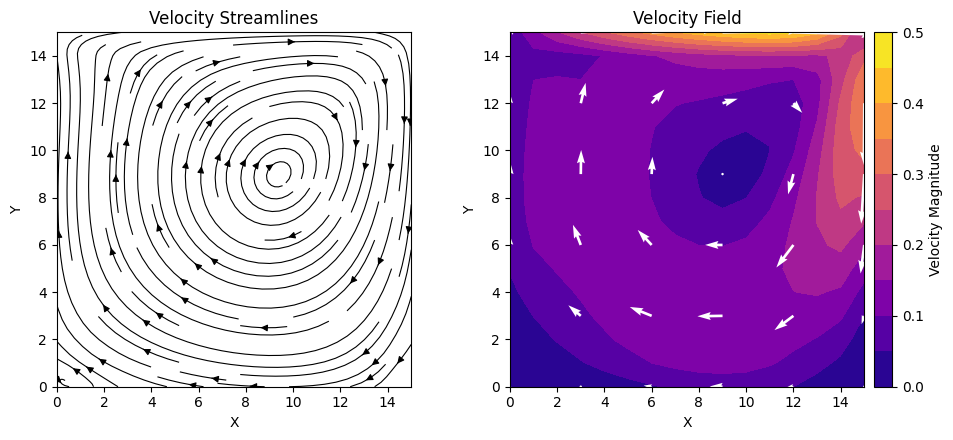

In [10]:

class CavityCase:
    def __init__(self, filename):
        self.filename = filename
        self.ds = self._load_results()

        # Extract core fields (assumes names U, V)
        self.U = self.ds["U"].values
        self.V = self.ds["V"].values

        self.x = self.ds["x"].values
        self.y = self.ds["y"].values
        self.X, self.Y = np.meshgrid(self.x, self.y)

        # Derived
        self.velocity_mag = np.sqrt(self.U**2 + self.V**2)

    def _load_results(self):
        with open(self.filename, "r") as f:
            lines = f.readlines()

        variable_line = next(line for line in lines if "VARIABLES" in line)
        columns = re.findall(r'"(.*?)"', variable_line)

        zone_line = [line for line in lines if "ZONE" in line][0]
        I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
        J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))

        print(f"Grid size: I={I}, J={J}")

        # Find data start
        data_start = 0
        for i, line in enumerate(lines):
            if re.match(r"\s*[-+0-9.]", line):
                data_start = i
                break

        data = np.loadtxt(self.filename, skiprows=data_start)
        data = data.reshape(J, I, len(columns))

        data_vars = {}
        for k, col in enumerate(columns):
            data_vars[col] = (("y", "x"), data[:, :, k])

        return xr.Dataset(
            data_vars,
            coords={"x": np.arange(I), "y": np.arange(J)},
        )

    def plot(self, step=3, density=1, scale=2, cmap="plasma"):
        fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

        # --- Contour + quiver ---
        contour = axs[1].contourf(
            self.X, self.Y, self.velocity_mag, levels=10, cmap=cmap
        )

        divider = make_axes_locatable(axs[1])
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(contour, label="Velocity Magnitude", cax=cax, shrink=0.8)

        axs[1].quiver(
            self.X[::step, ::step],
            self.Y[::step, ::step],
            self.U[::step, ::step],
            self.V[::step, ::step],
            color="white",
            scale=scale
        )

        # --- Streamlines ---
        axs[0].streamplot(
            self.X, self.Y, self.U, self.V,
            color='k',
            density=density,
            linewidth=0.8
        )

        # --- Formatting ---
        axs[1].set_title("Velocity Field")
        axs[0].set_title("Velocity Streamlines")

        for ax in axs:
            ax.set_xlim(self.x.min(), self.x.max())
            ax.set_ylim(self.y.min(), self.y.max())
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_aspect('equal', adjustable='box')

        fig.tight_layout()
        return fig, axs
case_1 = CavityCase("../case_data/1/1_result.dat")
case_1.plot()

In [4]:

class CavityCase:
    def __init__(self, ds, source=None):
        """
        Base constructor: expects a ready-to-use xarray Dataset.
        """
        self.ds = ds
        self.source = source

        # Extract fields
        self.U = self.ds["U"].values
        self.V = self.ds["V"].values

        self.x = self.ds["x"].values
        self.y = self.ds["y"].values
        self.X, self.Y = np.meshgrid(self.x, self.y)

        # Derived field
        self.velocity_mag = np.sqrt(self.U**2 + self.V**2)

    # =========================
    # Factory constructors
    # =========================
    @classmethod
    def from_file(cls, filename):
        ds = cls._load_results_static(filename)
        return cls(ds, source=filename)

    @classmethod
    def from_postprocess(cls, filepath):
        ds = xr.load_dataset(filepath)
        return cls(ds, source=filepath)

    # =========================
    # Internal loader
    # =========================
    @staticmethod
    def _load_results_static(filename):
        with open(filename, "r") as f:
            lines = f.readlines()

        # Extract variable names
        variable_line = next(line for line in lines if "VARIABLES" in line)
        columns = re.findall(r'"(.*?)"', variable_line)

        # Extract grid size
        zone_line = next(line for line in lines if "ZONE" in line)
        I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
        J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))

        print(f"Grid size: I={I}, J={J}")

        # Find start of numeric data
        data_start = 0
        for i, line in enumerate(lines):
            if re.match(r"\s*[-+0-9.]", line):
                data_start = i
                break

        # Load and reshape data
        data = np.loadtxt(filename, skiprows=data_start)
        data = data.reshape(J, I, len(columns))

        # Build dataset
        data_vars = {}
        for k, col in enumerate(columns):
            data_vars[col] = (("y", "x"), data[:, :, k])

        return xr.Dataset(
            data_vars,
            coords={"x": np.arange(I), "y": np.arange(J)},
        )

    # =========================
    # Save postprocessed data
    # =========================
    def save_postprocess(self, output_dir="postprocess_data", name=None):
        os.makedirs(output_dir, exist_ok=True)

        if name is None:
            base = os.path.basename(self.source) if self.source else "case"
            name = os.path.splitext(base)[0]

        filepath = os.path.join(output_dir, f"{name}.nc")

        self.ds.to_netcdf(filepath)
        print(f"Saved postprocessed data to: {filepath}")

        return filepath

    # =========================
    # Plotting
    # =========================
    def plot(self, step=3, density=1, scale=2, cmap="plasma"):
        fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

        # --- Contour + quiver ---
        contour = axs[1].contourf(
            self.X, self.Y, self.velocity_mag, levels=10, cmap=cmap
        )

        divider = make_axes_locatable(axs[1])
        cax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(contour, label="Velocity Magnitude", cax=cax, shrink=0.8)

        axs[1].quiver(
            self.X[::step, ::step],
            self.Y[::step, ::step],
            self.U[::step, ::step],
            self.V[::step, ::step],
            color="white",
            scale=scale
        )

        # --- Streamlines ---
        axs[0].streamplot(
            self.X, self.Y, self.U, self.V,
            color='k',
            density=density,
            linewidth=0.8
        )

        # --- Formatting ---
        axs[1].set_title("Velocity Field")
        axs[0].set_title("Velocity Streamlines")

        for ax in axs:
            ax.set_xlim(self.x.min(), self.x.max())
            ax.set_ylim(self.y.min(), self.y.max())
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            ax.set_aspect('equal', adjustable='box')

        fig.tight_layout()
        return fig, axs

In [5]:

def load_results(filename):
# Read file
    with open(filename, "r") as f:
        lines = f.readlines()
    variable_line = next(line for line in lines if "VARIABLES" in line)
    columns = re.findall(r'"(.*?)"', variable_line)
    # Extract I and J from ZONE line
    zone_line = [line for line in lines if "ZONE" in line][0]
    I = int(re.search(r"I=\s*(\d+)", zone_line).group(1))
    J = int(re.search(r"J=\s*(\d+)", zone_line).group(1))
    
    print(f"Grid size: I={I}, J={J}")
    # Find where numeric data starts
    data_start = 0
    for i, line in enumerate(lines):
        if re.match(r"\s*[-+0-9.]", line):
            data_start = i
            break

    # Load all numeric data at once
    data = np.loadtxt(filename, skiprows=data_start)

    # Reshape: (J, I, n_variables)
    data = data.reshape(J, I, len(columns))

    # Build xarray Dataset
    data_vars = {}
    for k, col in enumerate(columns):
        data_vars[col] = (("y", "x"), data[:, :, k])

    ds = xr.Dataset(
        data_vars,
        coords={
            "x": np.arange(I),
            "y": np.arange(J),
        },
    )
    return ds
    
filename ='../case_data/1/1_result.dat'
ds = load_results(filename)


Grid size: I=16, J=16


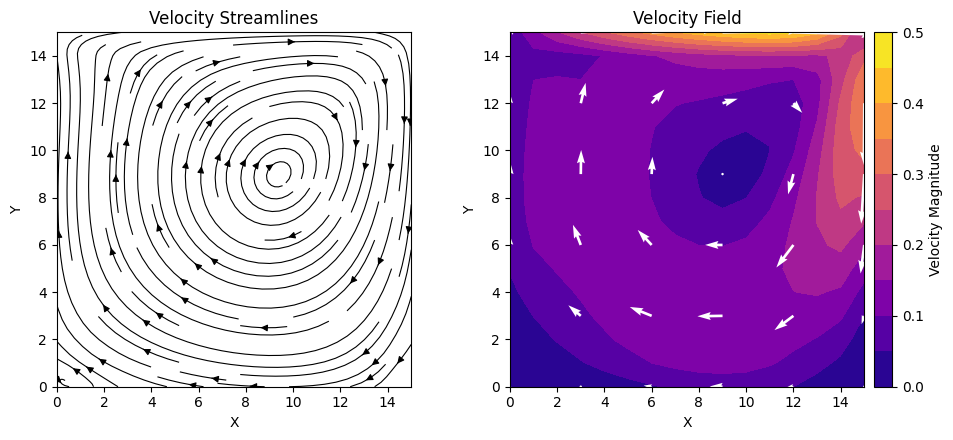

In [6]:


# --- Extract from dataset ---
U = ds["U"].values
V = ds["V"].values

x = ds["x"].values
y = ds["y"].values
X, Y = np.meshgrid(x, y)

# Velocity magnitude
velocity_mag = np.sqrt(U**2 + V**2)

# --- Plot ---
fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), sharex=False, sharey=False)

# --- Right subplot: contour + quiver ---
contour = axs[1].contourf(X, Y, velocity_mag, levels=10, cmap="plasma")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(contour, label="Velocity Magnitude", cax=cax, shrink=0.8)

# Quiver plot
step = 3
axs[1].quiver(
    X[::step, ::step],
    Y[::step, ::step],
    U[::step, ::step],
    V[::step, ::step],
    color="white",
    scale=2
    
)

# --- Left subplot: streamlines ---
axs[0].streamplot(
    X, Y, U, V,
    color='k',
    density=1,
    linewidth=0.8
)

# --- Titles ---
axs[1].set_title("Velocity Field")
axs[0].set_title("Velocity Streamlines")

# --- Formatting ---
for ax in axs:
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect('equal', adjustable='box')

fig.tight_layout()


In [7]:
importlib.reload(helpers)
CFDCase = helpers.CFDCase
case = CFDCase( "../case_data/0_quick2/0_result.dat")


AttributeError: module 'helpers' has no attribute 'CFDCase'

In [ ]:


ds = case.ds

X, Y = np.meshgrid(ds.x.values, ds.y.values)

plt.figure(figsize=(6,5))
plt.quiver(X, Y, ds.U.values, ds.V.values, scale=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Velocity Field (Re={ds.attrs['RE']})")
plt.axis("equal")
plt.tight_layout()
plt.show()
